In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam, SGD, AdamW
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
print("✅ Bibliotecas importadas.")

✅ Bibliotecas importadas.


In [26]:
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### Funções Auxiliares

In [27]:
def safe_div(a, b, fill=0.0):
    a = pd.to_numeric(a, errors='coerce').fillna(0)
    b = pd.to_numeric(b, errors='coerce').fillna(0)
    return np.where(b > 0, a / b, fill)

def handle_missing_mode(X, y):
    X_filled = X.copy()
    for col in X_filled.columns:
        if X_filled[col].isnull().any():
            moda = X_filled[col].mode()
            fill_val = moda.iloc[0] if len(moda) > 0 else 0
            X_filled[col] = X_filled[col].fillna(fill_val)
    return X_filled, y

def apply_label_encoding(X, cat_cols):
    X_enc = X.copy()
    for col in cat_cols:
        if col in X_enc.columns:
            le = LabelEncoder()
            vals = X_enc[col].fillna(-1).astype(str)
            X_enc[col] = le.fit_transform(vals)
    return X_enc

In [28]:
print("Carregando dados...")
COLS_CURSOS = [
    'QT_ING', 'QT_MAT', 'QT_CONC', 'QT_SIT_DESVINCULADO', 'QT_SIT_TRANCADA',
    'QT_VG_TOTAL', 'QT_VG_TOTAL_EAD', 'QT_VG_TOTAL_NOTURNO',
    'QT_ING_FEM', 'QT_ING_18_24', 'QT_INSCRITO_TOTAL',
    'QT_MAT_FINANC', 'QT_ING_FIES', 'QT_ING_PROUNIP',
    'TP_ORGANIZACAO_ACADEMICA', 'TP_REDE', 'TP_CATEGORIA_ADMINISTRATIVA',
    'TP_GRAU_ACADEMICO', 'TP_MODALIDADE_ENSINO', 'TP_DIMENSAO',
    'IN_GRATUITO', 'CO_CINE_AREA_GERAL',
]
cursos_df = pd.read_csv(
    'MICRODADOS_CADASTRO_CURSOS_2024.CSV',
    sep=';', encoding='latin1', low_memory=False,
    usecols=COLS_CURSOS
)
print(f"Cursos carregados: {cursos_df.shape[0]:,} linhas")

Carregando dados...
Cursos carregados: 720,349 linhas


In [29]:
df = cursos_df.copy()
count_cols = ['QT_ING','QT_MAT','QT_CONC','QT_SIT_DESVINCULADO','QT_SIT_TRANCADA',
              'QT_VG_TOTAL','QT_VG_TOTAL_EAD','QT_VG_TOTAL_NOTURNO',
              'QT_ING_FEM','QT_ING_18_24','QT_MAT_FINANC','QT_ING_FIES','QT_ING_PROUNIP']
for col in count_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['QT_EVADIDOS'] = df['QT_SIT_DESVINCULADO'] + df['QT_SIT_TRANCADA']
df['TAXA_EVASAO'] = safe_div(df['QT_EVADIDOS'], df['QT_ING']) * 100
df['ALTO_RISCO_EVASAO'] = (df['TAXA_EVASAO'] >= 20).astype(int)

df['TAXA_CONCLUSAO']       = safe_div(df['QT_CONC'], df['QT_MAT']) * 100
df['RAZAO_ING_MAT']        = safe_div(df['QT_ING'],  df['QT_MAT'])
df['PROPORCAO_EAD']        = safe_div(df['QT_VG_TOTAL_EAD'],    df['QT_VG_TOTAL'])
df['PROPORCAO_NOTURNO']    = safe_div(df['QT_VG_TOTAL_NOTURNO'], df['QT_VG_TOTAL'])
df['INDICE_FINANCIAMENTO'] = safe_div(df['QT_MAT_FINANC'],  df['QT_MAT'])
df['PROPORCAO_FIES']       = safe_div(df['QT_ING_FIES'],   df['QT_ING'])
df['PROPORCAO_PROUNIP']    = safe_div(df['QT_ING_PROUNIP'],df['QT_ING'])
df['PROPORCAO_18_24']      = safe_div(df['QT_ING_18_24'],  df['QT_ING'])
df['PROPORCAO_FEM']        = safe_div(df['QT_ING_FEM'],    df['QT_ING'])

CAT_FEATURES = [
    'TP_ORGANIZACAO_ACADEMICA', 'TP_REDE', 'TP_CATEGORIA_ADMINISTRATIVA',
    'TP_GRAU_ACADEMICO', 'TP_MODALIDADE_ENSINO', 'TP_DIMENSAO',
    'IN_GRATUITO', 'CO_CINE_AREA_GERAL'
]
NUM_FEATURES_RAW = ['QT_ING','QT_MAT','QT_VG_TOTAL','QT_INSCRITO_TOTAL']
DERIVED_FEATURES = [
    'TAXA_CONCLUSAO','RAZAO_ING_MAT','PROPORCAO_EAD','PROPORCAO_NOTURNO',
    'INDICE_FINANCIAMENTO','PROPORCAO_FIES','PROPORCAO_PROUNIP',
    'PROPORCAO_18_24','PROPORCAO_FEM'
]
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES_RAW + DERIVED_FEATURES
TARGET = 'ALTO_RISCO_EVASAO'

# Filtrar cursos com ingressantes > 0
df_clean = df[df['QT_ING'] > 0].copy()

# Amostrar 30.000 linhas (estratificado)
SAMPLE_SIZE = 30000
classes_df = []
for cls in df_clean[TARGET].unique():
    cls_df = df_clean[df_clean[TARGET] == cls]
    n_sample = int(SAMPLE_SIZE * len(cls_df) / len(df_clean))
    n_sample = min(n_sample, len(cls_df))
    classes_df.append(cls_df.sample(n=n_sample, random_state=42))
dataset_sample = pd.concat(classes_df).sample(frac=1, random_state=42).reset_index(drop=True)

X_raw = dataset_sample[ALL_FEATURES].copy()
y_raw = dataset_sample[TARGET].copy()

# Aplicar baseline: missing=mode, encoding=label, sem escalonamento, sem balanceamento, sem seleção
X_mode, y_mode = handle_missing_mode(X_raw, y_raw)
X_encoded = apply_label_encoding(X_mode, CAT_FEATURES)

# Converter para float (garantir compatibilidade com redes neurais)
X_processed = X_encoded.astype(np.float32)
y_processed = y_mode.values.astype(np.float32)

print(f"Dados processados: {X_processed.shape[0]} amostras, {X_processed.shape[1]} features")
print(f"Distribuição do target: {np.bincount(y_processed.astype(int))}")

Dados processados: 29999 amostras, 21 features
Distribuição do target: [ 7377 22622]


Top 10 features por importância (Random Forest):
                     feature  RF_importance  Mutual_info
13             RAZAO_ING_MAT       0.233348     0.164421
9                     QT_MAT       0.157193     0.115546
8                     QT_ING       0.139767     0.073345
7         CO_CINE_AREA_GERAL       0.116473     0.006374
12            TAXA_CONCLUSAO       0.066956     0.051690
20             PROPORCAO_FEM       0.065645     0.047296
19           PROPORCAO_18_24       0.064786     0.053284
16      INDICE_FINANCIAMENTO       0.049643     0.024206
0   TP_ORGANIZACAO_ACADEMICA       0.037181     0.003675
3          TP_GRAU_ACADEMICO       0.031425     0.004633

Top 10 features por Informação Mútua:
RAZAO_ING_MAT           0.164421
QT_MAT                  0.115546
QT_ING                  0.073345
PROPORCAO_18_24         0.053284
TAXA_CONCLUSAO          0.051690
PROPORCAO_FEM           0.047296
INDICE_FINANCIAMENTO    0.024206
TP_MODALIDADE_ENSINO    0.011343
TP_DIMENSAO          

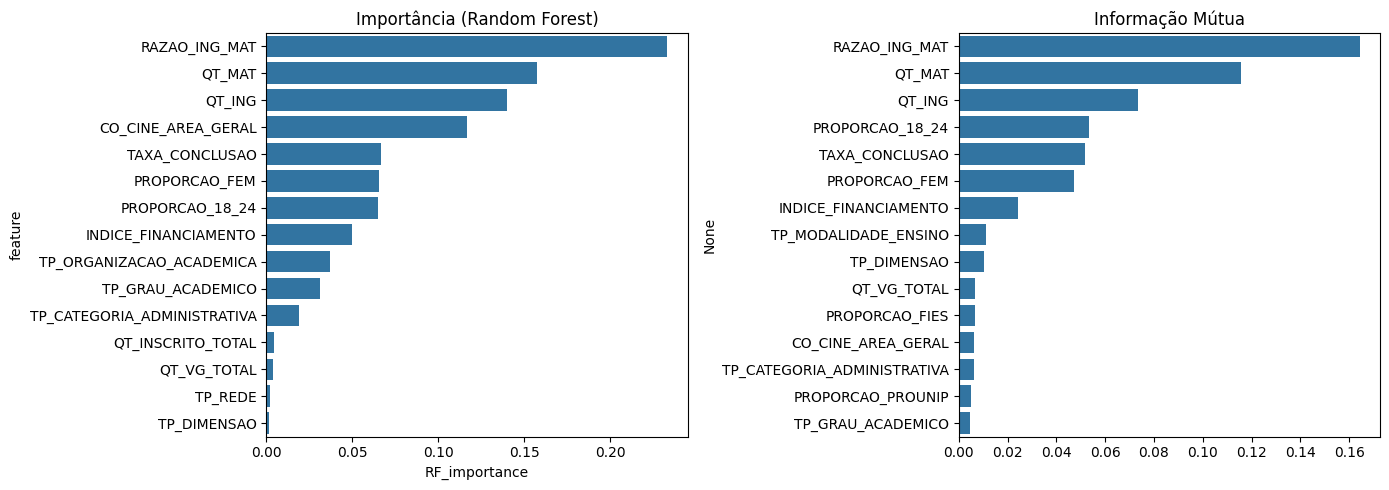

In [30]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_processed, y_processed)
importances = rf.feature_importances_
feat_names = X_processed.columns

# Informação Mútua
mi = mutual_info_classif(X_processed, y_processed, random_state=42)
mi_series = pd.Series(mi, index=feat_names).sort_values(ascending=False)

# DataFrame de importâncias
imp_df = pd.DataFrame({
    'feature': feat_names,
    'RF_importance': importances,
    'Mutual_info': mi
}).sort_values('RF_importance', ascending=False)

print("Top 10 features por importância (Random Forest):")
print(imp_df.head(10))

print("\nTop 10 features por Informação Mútua:")
print(mi_series.head(10))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='RF_importance', y='feature', data=imp_df.head(15), ax=axes[0])
axes[0].set_title('Importância (Random Forest)')
sns.barplot(x=mi_series.head(15).values, y=mi_series.head(15).index, ax=axes[1])
axes[1].set_title('Informação Mútua')
plt.tight_layout()
plt.show()

Variância explicada pelos 2 primeiros PCs: 0.9183


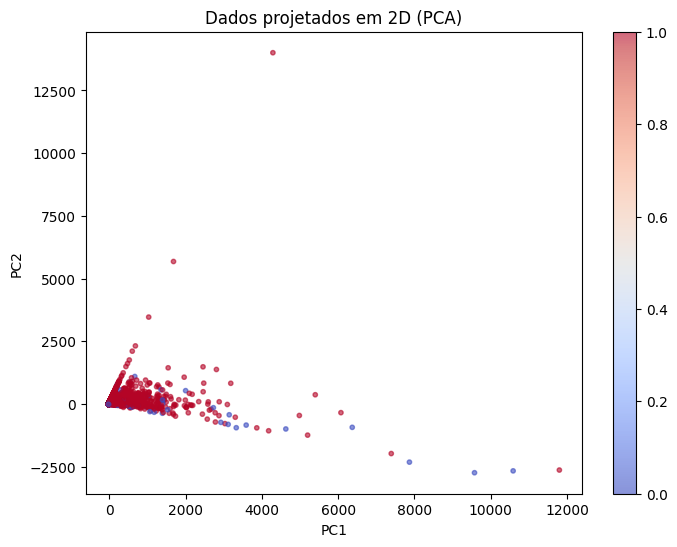

In [31]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(f"Variância explicada pelos 2 primeiros PCs: {pca.explained_variance_ratio_.sum():.4f}")
# Plot dos dados em 2D
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_processed, cmap='coolwarm', alpha=0.6, s=10)
plt.colorbar(scatter)
plt.title('Dados projetados em 2D (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Rede Neural

In [32]:
n_features = X_processed.shape[1]
n_neurons = (n_features + 1) // 2
print(f"Número de features: {n_features}, neurônios na 1ª camada oculta: {n_neurons}")

Número de features: 21, neurônios na 1ª camada oculta: 11


In [33]:
def build_perceptron():
    model = Sequential([
        Dense(1, input_dim=n_features, activation='sigmoid')  # perceptron linear = regressão logística
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [34]:
def build_perceptron_nonlinear():
    model = Sequential([
        Dense(10, input_dim=n_features, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [35]:
def build_mlp_1hidden():
    model = Sequential([
        Dense(n_neurons, input_dim=n_features, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [36]:
def build_mlp_2hidden():
    model = Sequential([
        Dense(n_neurons, input_dim=n_features, activation='relu'),
        Dense(3, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [56]:
def build_mlp_backprop(n_features, n_neurons):
    # MLP 1 hidden com SGD (backpropagation tradicional)
    model = Sequential([
        Dense(n_neurons, input_dim=n_features, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [38]:
models_dict = {
    'Perceptron (Linear)': build_perceptron,
    'Perceptron Não‑linear': build_perceptron_nonlinear,
    'MLP 1 camada oculta': build_mlp_1hidden,
    'MLP 2 camadas ocultas': build_mlp_2hidden,
    'MLP 1 camada + Backprop (SGD)': build_mlp_backprop
}


Treinando Perceptron (Linear)...
  Acurácia: 0.7540, F1: 0.8596

Treinando Perceptron Não‑linear...
  Acurácia: 0.8293, F1: 0.8897

Treinando MLP 1 camada oculta...
  Acurácia: 0.8278, F1: 0.8866

Treinando MLP 2 camadas ocultas...
  Acurácia: 0.8270, F1: 0.8846

Treinando MLP 1 camada + Backprop (SGD)...
  Acurácia: 0.7542, F1: 0.8599


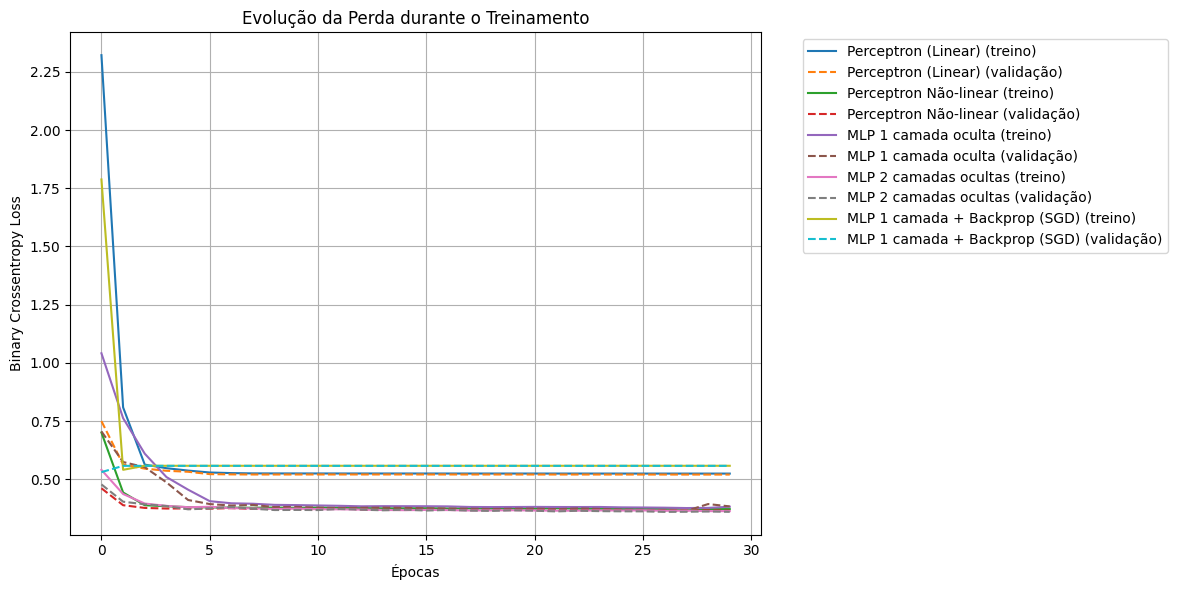

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)

histories = {}
trained_models = {}
epochs = 30
batch_size = 32

for name, builder in models_dict.items():
    print(f"\nTreinando {name}...")
    model = builder()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    trained_models[name] = model
    histories[name] = history
    # Avaliação final
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    print(f"  Acurácia: {acc:.4f}, F1: {f1:.4f}")


plt.figure(figsize=(12,6))
for name, hist in histories.items():
    plt.plot(hist.history['loss'], label=f'{name} (treino)')
    plt.plot(hist.history['val_loss'], '--', label=f'{name} (validação)')
plt.xlabel('Épocas')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Evolução da Perda durante o Treinamento')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

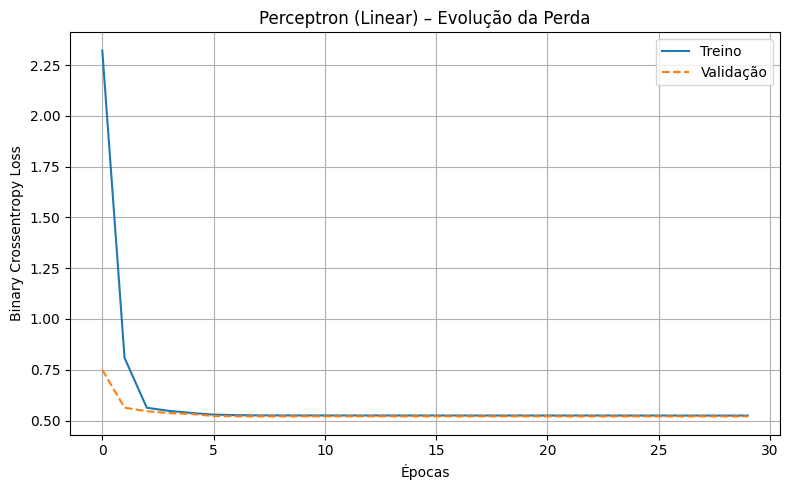

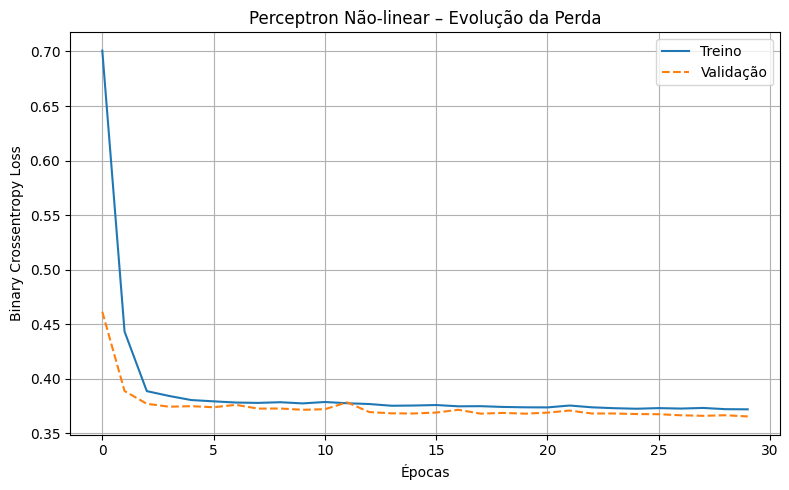

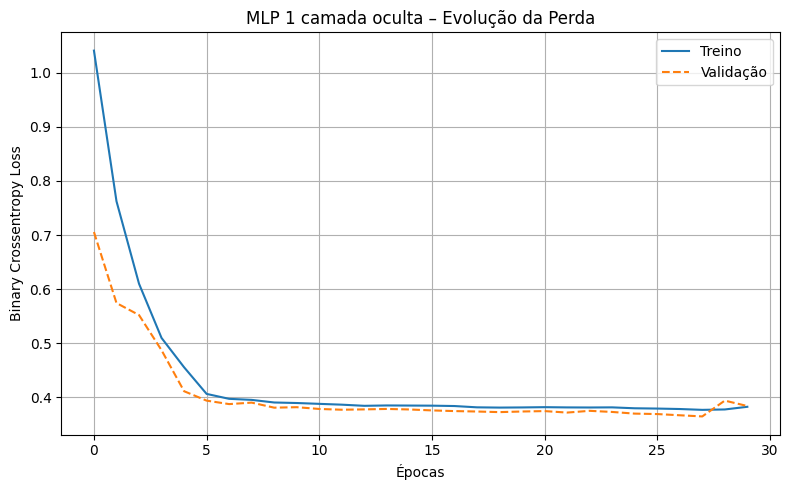

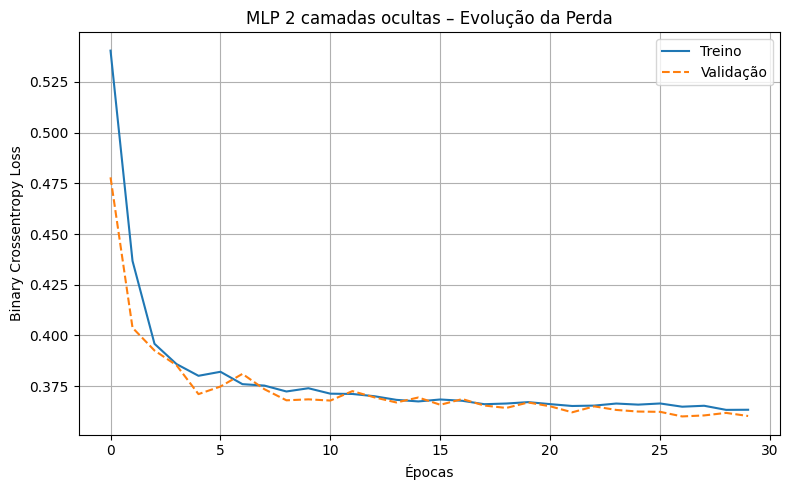

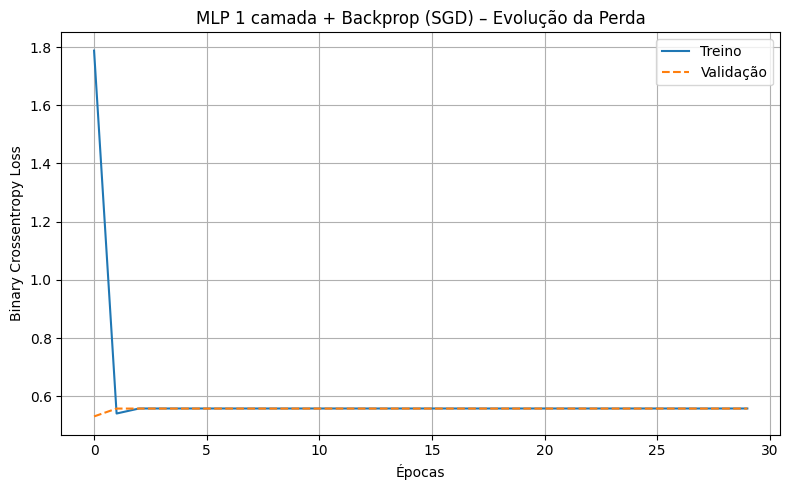

In [40]:
for name, hist in histories.items():
    plt.figure(figsize=(8,5))
    plt.plot(hist.history['loss'], label='Treino')
    plt.plot(hist.history['val_loss'], '--', label='Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Binary Crossentropy Loss')
    plt.title(f'{name} – Evolução da Perda')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [41]:
def plot_decision_boundary(model, X, y, title, ax=None):
    if ax is None:
        ax = plt.gca()
    # Grade
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # Previsões
    Z = model.predict(grid, verbose=0)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)
    # Plot
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='RdYlBu', s=20)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

In [42]:
pca_models = {}
for name, builder in models_dict.items():
    # Reconstruir o mesmo modelo com input_dim=2
    if name == 'Perceptron (Linear)':
        model = Sequential([Dense(1, input_dim=2, activation='sigmoid')])
        model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    elif name == 'Perceptron Não‑linear':
        model = Sequential([Dense(10, input_dim=2, activation='relu'), Dense(1, activation='sigmoid')])
        model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    elif name == 'MLP 1 camada oculta':
        model = Sequential([Dense(n_neurons, input_dim=2, activation='relu'), Dense(1, activation='sigmoid')])
        model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    elif name == 'MLP 2 camadas ocultas':
        model = Sequential([Dense(n_neurons, input_dim=2, activation='relu'), Dense(3, activation='relu'), Dense(1, activation='sigmoid')])
        model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    else:  # MLP 1 camada + Backprop
        model = Sequential([Dense(n_neurons, input_dim=2, activation='relu'), Dense(1, activation='sigmoid')])
        model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_pca, y_processed, epochs=30, batch_size=32, verbose=0)
    pca_models[name] = model

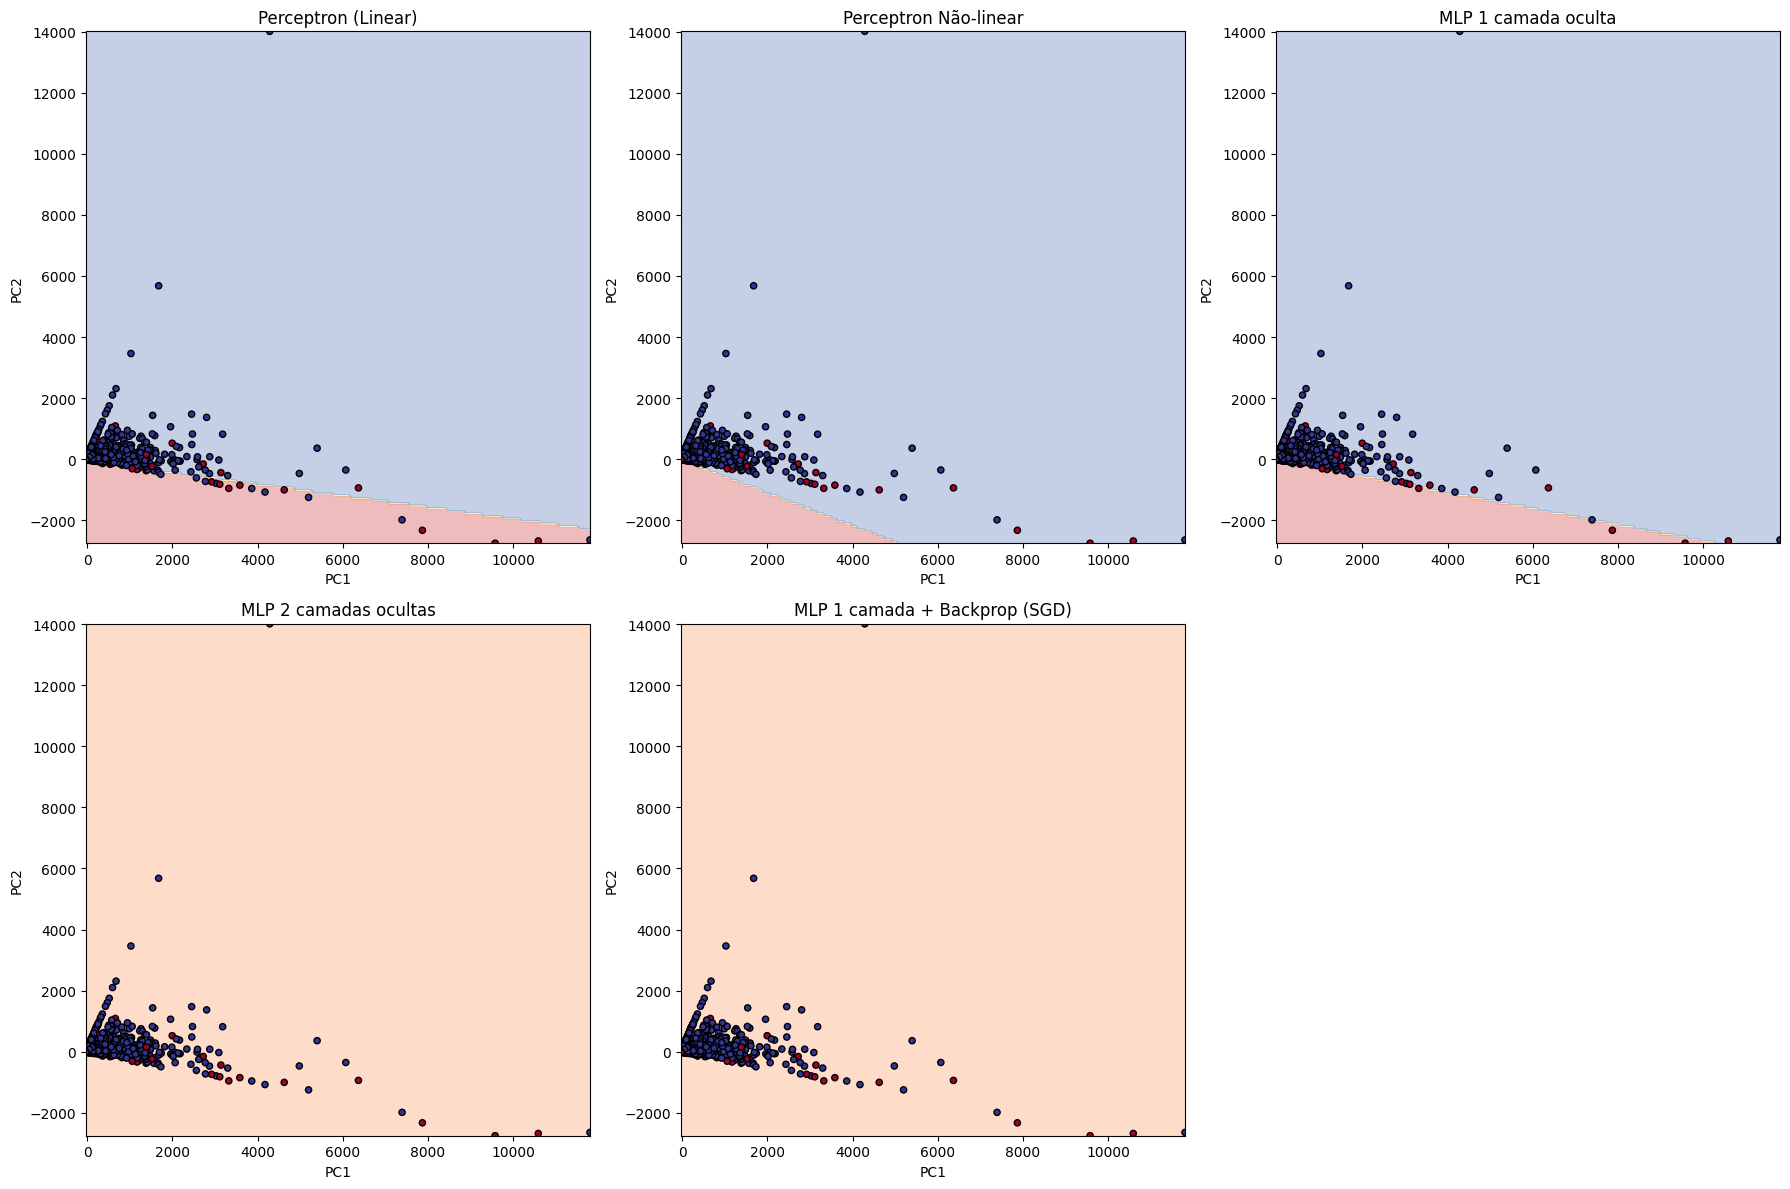

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
for idx, (name, model) in enumerate(pca_models.items()):
    plot_decision_boundary(model, X_pca, y_processed, name, ax=axes[idx])
# O sexto subplot pode ficar vazio
if len(pca_models) < 6:
    axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [54]:
def get_class_weights(y):
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y),
        y=y
    )
    return {0: class_weights[0], 1: class_weights[1]}

In [55]:
def find_best_threshold(model, X_calib, y_calib):
    y_proba_calib = model.predict(X_calib, verbose=0).flatten()
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_thr = 0.5
    for thr in thresholds:
        y_pred_calib = (y_proba_calib > thr).astype(int)
        f1 = f1_score(y_calib, y_pred_calib)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1

In [45]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Pesos das classes:", weight_dict)

Pesos das classes: {0: np.float64(2.033124364622162), 1: np.float64(0.6630657014974858)}


In [46]:
epochs = 30
batch_size = 32

histories_bal = {}
trained_models_bal = {}

for name, builder in models_dict.items():
    print(f"\nTreinando {name} COM balanceamento...")
    model = builder()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=weight_dict,   # <-- balanceamento aqui
        verbose=0
    )
    trained_models_bal[name] = model
    histories_bal[name] = history
    # Avaliação inicial com threshold 0.5
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    print(f"  Acurácia: {accuracy_score(y_test, y_pred):.4f}, F1: {f1:.4f}")


Treinando Perceptron (Linear) COM balanceamento...
  Acurácia: 0.5943, F1: 0.6658

Treinando Perceptron Não‑linear COM balanceamento...
  Acurácia: 0.7833, F1: 0.8391

Treinando MLP 1 camada oculta COM balanceamento...
  Acurácia: 0.7885, F1: 0.8442

Treinando MLP 2 camadas ocultas COM balanceamento...
  Acurácia: 0.8035, F1: 0.8593

Treinando MLP 1 camada + Backprop (SGD) COM balanceamento...
  Acurácia: 0.7982, F1: 0.8560


In [47]:
print("\n" + "="*70)
print(" AJUSTE DE LIMIAR PARA CADA MODELO")
print("="*70)

thresholds = np.arange(0.1, 0.9, 0.05)
best_thresholds = {}

for name, model in trained_models_bal.items():
    # Probabilidades no teste
    y_proba = model.predict(X_test, verbose=0).flatten()
    best_f1 = 0
    best_thr = 0.5
    for thr in thresholds:
        y_pred = (y_proba > thr).astype(int)
        f1 = f1_score(y_test, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    best_thresholds[name] = best_thr
    print(f"{name:30s} -> Melhor limiar: {best_thr:.2f} (F1={best_f1:.4f})")


 AJUSTE DE LIMIAR PARA CADA MODELO
Perceptron (Linear)            -> Melhor limiar: 0.10 (F1=0.8597)
Perceptron Não‑linear          -> Melhor limiar: 0.20 (F1=0.8882)
MLP 1 camada oculta            -> Melhor limiar: 0.20 (F1=0.8890)
MLP 2 camadas ocultas          -> Melhor limiar: 0.25 (F1=0.8889)
MLP 1 camada + Backprop (SGD)  -> Melhor limiar: 0.30 (F1=0.8903)


In [48]:
print("\n" + "="*70)
print(" AVALIAÇÃO FINAL (COM LIMIAR OTIMIZADO)")
print("="*70)

results_bal = []
for name, model in trained_models_bal.items():
    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_proba > best_thresholds[name]).astype(int)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    results_bal.append({
        'modelo': name,
        'threshold': best_thresholds[name],
        'accuracy': acc,
        'f1_score': f1,
        'precision': prec,
        'recall': rec
    })

df_results_bal = pd.DataFrame(results_bal)
print(df_results_bal.to_string(index=False))


 AVALIAÇÃO FINAL (COM LIMIAR OTIMIZADO)
                       modelo  threshold  accuracy  f1_score  precision   recall
          Perceptron (Linear)       0.10  0.754000  0.859749   0.754126 0.999779
        Perceptron Não‑linear       0.20  0.828500  0.888237   0.873345 0.903646
          MLP 1 camada oculta       0.20  0.826333  0.888984   0.858260 0.921989
        MLP 2 camadas ocultas       0.25  0.827667  0.888913   0.864938 0.914254
MLP 1 camada + Backprop (SGD)       0.30  0.833500  0.890328   0.884599 0.896133


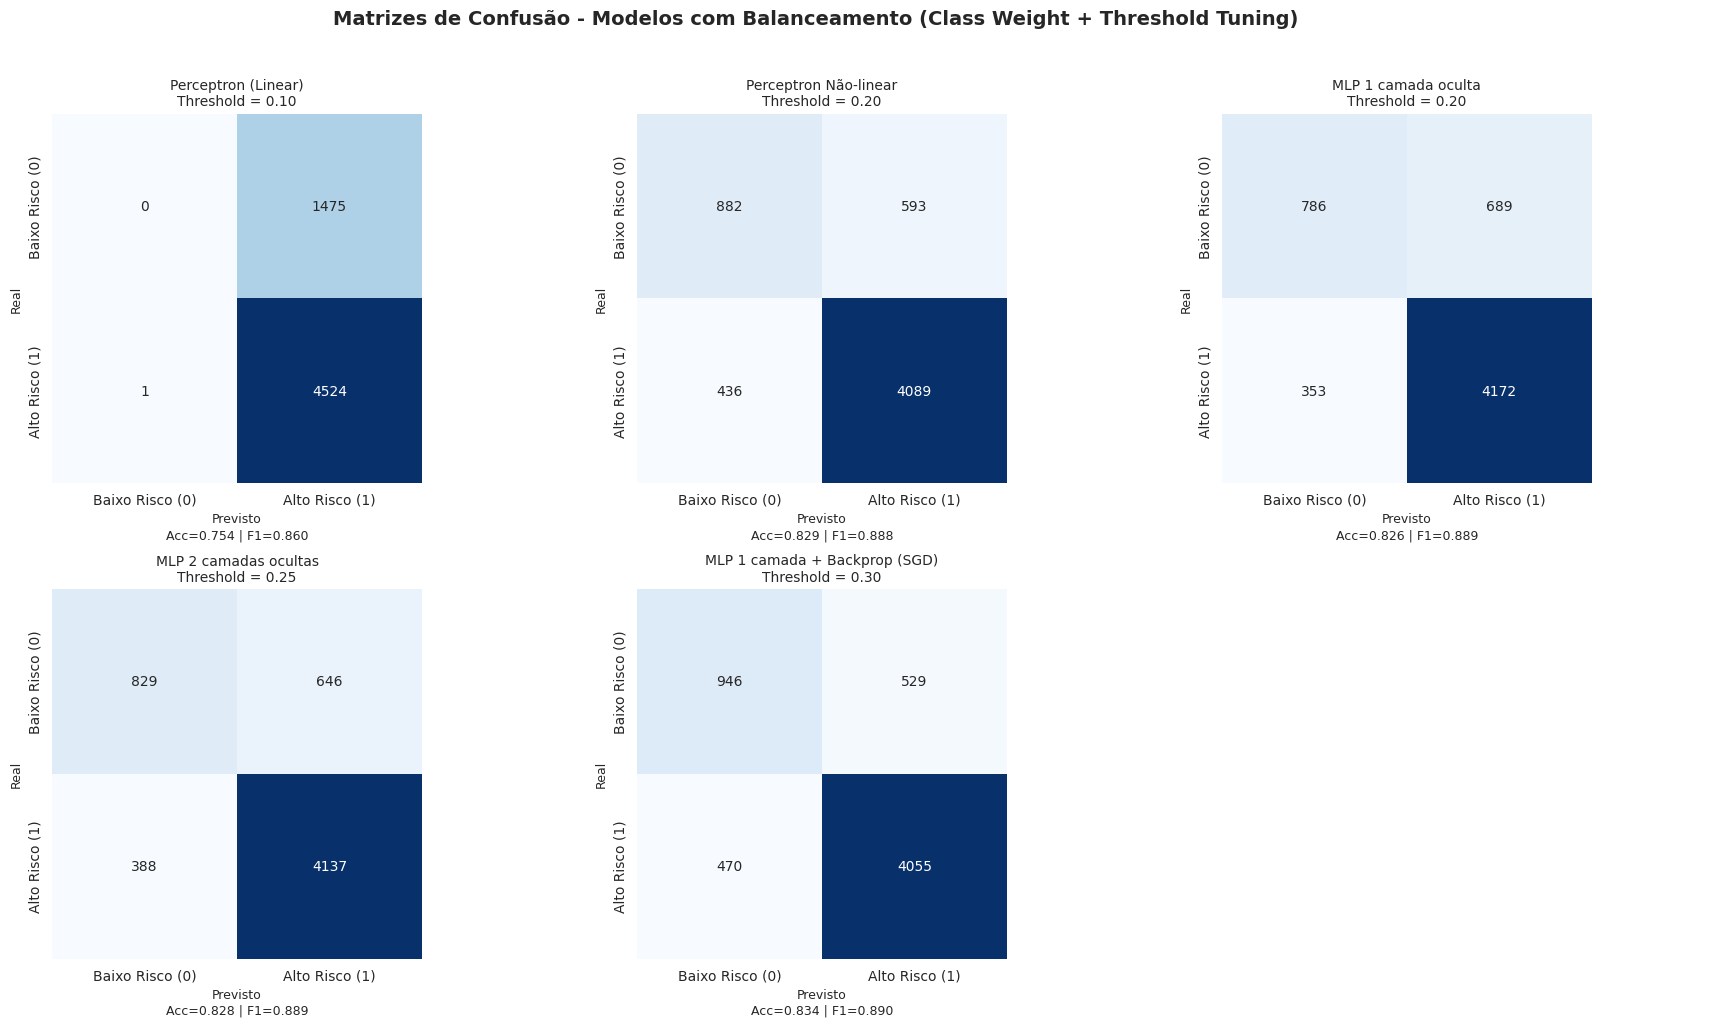

In [49]:
# ============================================================================
# MATRIZES DE CONFUSÃO COM SEABORN (Modelos Balanceados)
# ============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Configurar estilo do seaborn
sns.set_style("whitegrid")
sns.set_palette("pastel")

# Criar subplots (2 linhas, 3 colunas) para 5 modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Para cada modelo, calcular e plotar a matriz de confusão
for idx, (name, model) in enumerate(trained_models_bal.items()):
    if idx >= len(axes):
        break

    ax = axes[idx]

    # Previsões com o limiar otimizado
    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_proba > best_thresholds[name]).astype(int)

    # Calcular matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    # Plotar heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Baixo Risco (0)', 'Alto Risco (1)'],
                yticklabels=['Baixo Risco (0)', 'Alto Risco (1)'],
                ax=ax, cbar=False, square=True)

    # Títulos e rótulos
    ax.set_title(f'{name}\nThreshold = {best_thresholds[name]:.2f}', fontsize=10)
    ax.set_xlabel('Previsto', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

    # Adicionar métricas no canto da matriz
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    ax.text(0.5, -0.15, f'Acc={acc:.3f} | F1={f1:.3f}',
            transform=ax.transAxes, ha='center', fontsize=9)

# Ocultar subplot não utilizado (6º)
axes[-1].axis('off')

plt.suptitle('Matrizes de Confusão - Modelos com Balanceamento (Class Weight + Threshold Tuning)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [57]:
N_FOLDS    = 5
EPOCHS     = 30
BATCH_SIZE = 32

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_metrics = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'threshold': []}
fold_details = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_processed, y_processed), start=1):
    print(f'\n{"="*60}')
    print(f' FOLD {fold_idx}/{N_FOLDS}')
    print(f'{"="*60}')

    X_train_fold, X_val_fold = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_train_fold, y_val_fold = y_processed[train_idx], y_processed[val_idx]

    # ── Sub-split interno do treino para calibração do threshold (sem leakage) ──
    X_tr_inner, X_calib, y_tr_inner, y_calib = train_test_split(
        X_train_fold, y_train_fold,
        test_size=0.2, random_state=42, stratify=y_train_fold
    )

    # ── Class weights calculados a partir do treino interno do fold ──
    weight_dict = get_class_weights(y_tr_inner)

    # ── Treinar o modelo ──
    model = build_mlp_backprop(n_features, n_neurons)
    model.fit(
        X_tr_inner, y_tr_inner,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        class_weight=weight_dict,
        verbose=0
    )

    # ── Buscar threshold ótimo na calibração (não no fold de validação) ──
    best_thr, calib_f1 = find_best_threshold(model, X_calib, y_calib)

    # ── Avaliar no fold de validação, usando o threshold calibrado ──
    y_proba_val = model.predict(X_val_fold, verbose=0).flatten()
    y_pred_val  = (y_proba_val > best_thr).astype(int)

    acc  = accuracy_score(y_val_fold, y_pred_val)
    f1   = f1_score(y_val_fold, y_pred_val, zero_division=0)
    prec = precision_score(y_val_fold, y_pred_val, zero_division=0)
    rec  = recall_score(y_val_fold, y_pred_val, zero_division=0)

    fold_metrics['accuracy'].append(acc)
    fold_metrics['f1'].append(f1)
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['threshold'].append(best_thr)

    fold_details.append({
        'fold': fold_idx, 'threshold': best_thr,
        'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec
    })

    print(f'  Threshold calibrado : {best_thr:.2f}  (F1 calibração = {calib_f1:.4f})')
    print(f'  Acurácia (validação) : {acc:.4f}')
    print(f'  F1       (validação) : {f1:.4f}')
    print(f'  Precisão (validação) : {prec:.4f}')
    print(f'  Recall   (validação) : {rec:.4f}')

print('\n✅ Validação cruzada concluída.')


 FOLD 1/5
  Threshold calibrado : 0.10  (F1 calibração = 0.8599)
  Acurácia (validação) : 0.7542
  F1       (validação) : 0.8599
  Precisão (validação) : 0.7542
  Recall   (validação) : 1.0000

 FOLD 2/5
  Threshold calibrado : 0.20  (F1 calibração = 0.8829)
  Acurácia (validação) : 0.8245
  F1       (validação) : 0.8865
  Precisão (validação) : 0.8650
  Recall   (validação) : 0.9092

 FOLD 3/5
  Threshold calibrado : 0.20  (F1 calibração = 0.8906)
  Acurácia (validação) : 0.8218
  F1       (validação) : 0.8873
  Precisão (validação) : 0.8482
  Recall   (validação) : 0.9302

 FOLD 4/5
  Threshold calibrado : 0.25  (F1 calibração = 0.8850)
  Acurácia (validação) : 0.8218
  F1       (validação) : 0.8853
  Precisão (validação) : 0.8600
  Recall   (validação) : 0.9122

 FOLD 5/5
  Threshold calibrado : 0.25  (F1 calibração = 0.8884)
  Acurácia (validação) : 0.8300
  F1       (validação) : 0.8908
  Precisão (validação) : 0.8639
  Recall   (validação) : 0.9193

✅ Validação cruzada concluída

In [58]:
df_folds = pd.DataFrame(fold_details)
print('Resultados por fold:')
print(df_folds.to_string(index=False))

print('\n' + '=' * 60)
print(' RESUMO — MLP 1 camada + Backprop (SGD) — 5-Fold CV')
print('=' * 60)

summary = {}
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    values = np.array(fold_metrics[metric])
    mean_val, std_val = values.mean(), values.std()
    summary[metric] = {'mean': mean_val, 'std': std_val}
    print(f'  {metric.capitalize():<10}: {mean_val:.4f} ± {std_val:.4f}')

print(f"\n  Threshold médio usado: {np.mean(fold_metrics['threshold']):.3f} "
      f"± {np.std(fold_metrics['threshold']):.3f}")

Resultados por fold:
 fold  threshold  accuracy       f1  precision   recall
    1       0.10  0.754167 0.859857   0.754167 1.000000
    2       0.20  0.824500 0.886542   0.865013 0.909171
    3       0.20  0.821833 0.887296   0.848216 0.930150
    4       0.25  0.821833 0.885337   0.859971 0.912246
    5       0.25  0.829972 0.890769   0.863939 0.919319

 RESUMO — MLP 1 camada + Backprop (SGD) — 5-Fold CV
  Accuracy  : 0.8105 ± 0.0283
  F1        : 0.8820 ± 0.0112
  Precision : 0.8383 ± 0.0425
  Recall    : 0.9342 ± 0.0337

  Threshold médio usado: 0.200 ± 0.055


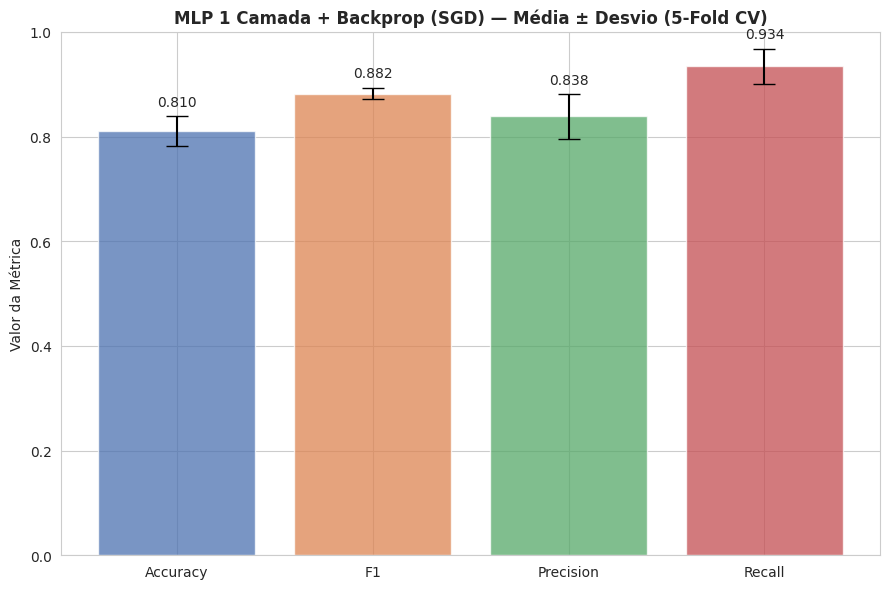

✅ Salvo: nn_cv_metrics.png


In [59]:
# ── Visualização: dispersão das métricas entre folds ──
fig, ax = plt.subplots(figsize=(9, 6))
metrics_to_plot = ['accuracy', 'f1', 'precision', 'recall']
positions = np.arange(len(metrics_to_plot))

means = [summary[m]['mean'] for m in metrics_to_plot]
stds  = [summary[m]['std']  for m in metrics_to_plot]

ax.bar(positions, means, yerr=stds, capsize=8, alpha=0.75,
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.set_xticks(positions)
ax.set_xticklabels([m.capitalize() for m in metrics_to_plot])
ax.set_ylabel('Valor da Métrica')
ax.set_ylim(0, 1)
ax.set_title('MLP 1 Camada + Backprop (SGD) — Média ± Desvio (5-Fold CV)',
              fontweight='bold')
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('nn_cv_metrics.png', dpi=150)
plt.show()
print('✅ Salvo: nn_cv_metrics.png')

In [60]:
results_nn = {
    'modelo': 'Rede Neural (MLP 1 camada + SGD)',
    'accuracy_mean':  summary['accuracy']['mean'],
    'accuracy_std':   summary['accuracy']['std'],
    'f1_mean':        summary['f1']['mean'],
    'f1_std':         summary['f1']['std'],
    'precision_mean': summary['precision']['mean'],
    'precision_std':  summary['precision']['std'],
    'recall_mean':    summary['recall']['mean'],
    'recall_std':     summary['recall']['std'],
    'threshold_mean': np.mean(fold_metrics['threshold']),
    'notas': 'class_weight balanced + threshold tuning calibrado sem leakage (sub-split do treino)'
}

pd.DataFrame([results_nn]).to_csv('resultados_rede_neural_5fold.csv', index=False)
df_folds.to_csv('resultados_rede_neural_5fold_por_fold.csv', index=False)

print('📊 Salvos:')
print('  - resultados_rede_neural_5fold.csv (resumo)')
print('  - resultados_rede_neural_5fold_por_fold.csv (detalhe por fold)')
print()
print('Resumo final:')
for k, v in results_nn.items():
    if isinstance(v, float):
        print(f'  {k:<15}: {v:.4f}')
    else:
        print(f'  {k:<15}: {v}')

📊 Salvos:
  - resultados_rede_neural_5fold.csv (resumo)
  - resultados_rede_neural_5fold_por_fold.csv (detalhe por fold)

Resumo final:
  modelo         : Rede Neural (MLP 1 camada + SGD)
  accuracy_mean  : 0.8105
  accuracy_std   : 0.0283
  f1_mean        : 0.8820
  f1_std         : 0.0112
  precision_mean : 0.8383
  precision_std  : 0.0425
  recall_mean    : 0.9342
  recall_std     : 0.0337
  threshold_mean : 0.2000
  notas          : class_weight balanced + threshold tuning calibrado sem leakage (sub-split do treino)
